# Beginner Notebook: Patient Capital and ESG

This notebook explains the full project step by step for beginners.

## Main research question
**Does patient capital improve corporate ESG performance?**

## Dataset
- Chinese A-share listed firms
- Years: 2010-2024
- About 32,023 firm-year observations
- Core proxies of patient capital:
  - `Rdebt`: relational long-term debt orientation
  - `Invest`: strategic equity stability/intensity proxy

We will cover:
1. Concept and variable definitions
2. Data inspection and cleaning checks
3. Visualization and descriptive analysis
4. Baseline econometric models
5. Robustness checks and interpretation


## 0) Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

print('Libraries loaded.')

Libraries loaded.


## 1) Load Project Data

In [2]:
DATA_PATH = r'论文数据0208/论文数据0208/Deliverable/analysis_data.csv'
BASELINE_RDEBT_PATH = r'论文数据0208/论文数据0208/python_replication/table3_baseline_rdebt.csv'
BASELINE_INVEST_PATH = r'论文数据0208/论文数据0208/python_replication/table3_baseline_invest.csv'

df = pd.read_csv(DATA_PATH)
baseline_rdebt = pd.read_csv(BASELINE_RDEBT_PATH)
baseline_invest = pd.read_csv(BASELINE_INVEST_PATH)

print('Data shape:', df.shape)
print('Year range:', int(df['Year'].min()), '-', int(df['Year'].max()))
print('Unique firms:', df['Scode'].nunique())
df.head()

Data shape: (32023, 48)
Year range: 2010 - 2024
Unique firms: 4316


,Scode,Year,ESG_rating,ESG_Score,E_Score,S_Score,G_Score,hangye,ESG,Rdebt,Invest,TOP1,Typrep,Cashflow,Growth,Size,Lev,ROA,Source,NetProfit,Dual,TobinQ,IndustryCode,Indep,Age,La,SA,KZ,WW,FC,SOE,AgencyCost,IneffInvest,IneffSign,OverInvest,UnderInvest,RD_exp,ln_RD,TotalPatent,Invia,ln_Patent,ln_Invention,AnaAttention,ln_AnaAttention,HeavyPollution,LargeFirm,PositiveCF,HighAnalyst
0,2,2010,BBB,83.93,70.80,91.05,81.53,房地产业,6.0,0.190074,0.041515,14.73,A,0.044115,4.046833,26.096865,0.746861,0.040993,0,0.174304,0,1.165389,J01,0.3636,3.258097,0.940386,-3.605597,3.106747,-1.180166,0.036184,1.0,0.036408,0.006788,1.0,0.006788,0.000000,NaN,NaN,26,11,3.295837,2.484907,43.0,3.784190,0,1,1,1
1,2,2011,BBB,81.81,67.21,92.72,76.29,房地产业,6.0,0.117448,0.088274,14.73,A,0.047218,3.557566,26.414330,0.770997,0.039160,0,0.161593,0,1.042680,J01,0.3636,3.295837,0.940386,-3.539929,4.828872,-1.218107,0.017276,1.0,0.035917,0.018746,1.0,0.018746,0.000000,NaN,NaN,4,0,1.609438,0.000000,43.0,3.784190,0,1,1,1
2,2,2012,BBB,84.27,65.41,91.88,83.28,房地产业,6.0,0.121471,0.120660,14.72,A,0.036134,2.699265,26.535147,0.783163,0.041348,0,0.151893,0,1.076892,K70,0.3636,3.332205,0.940386,-3.492107,4.800067,-1.220772,0.012737,1.0,0.026963,0.005664,0.0,0.000000,0.005664,NaN,NaN,5,2,1.791759,1.098612,43.0,3.784190,0,1,1,1
3,2,2013,BBB,83.46,70.80,93.64,77.99,房地产业,6.0,0.117939,0.104915,14.70,A,0.014207,2.269174,26.535147,0.779970,0.038183,0,0.135118,0,0.968694,K70,0.3636,3.367296,0.922458,-3.443290,2.967212,-1.227200,0.022137,1.0,0.022174,0.001072,1.0,0.001072,0.000000,NaN,NaN,5,3,1.791759,1.386294,43.0,3.784190,0,1,1,1
4,2,2014,BBB,83.41,63.61,92.30,81.53,房地产业,6.0,0.117572,0.121494,14.91,A,0.285029,2.753701,26.535147,0.772046,0.037937,0,0.131756,0,1.064914,K70,0.3636,3.401197,0.914236,-3.460194,2.046928,-1.241766,0.013056,1.0,0.026659,0.010051,0.0,0.000000,0.010051,NaN,NaN,38,8,3.663562,2.197225,38.0,3.663562,0,1,1,1


## 2) Understand the Variables

Below is a beginner-friendly dictionary for the most important variables.

In [3]:
variable_dict = pd.DataFrame([
    ('ESG', 'Dependent variable: ESG rating mapped to ordinal score (1-9)'),
    ('ESG_Score', 'Continuous ESG total score'),
    ('E_Score', 'Environmental sub-score'),
    ('S_Score', 'Social sub-score'),
    ('G_Score', 'Governance sub-score'),
    ('Rdebt', 'Patient capital proxy 1: long-term debt orientation'),
    ('Invest', 'Patient capital proxy 2: strategic equity stability/intensity'),
    ('Age', 'Firm age (log years since listing)'),
    ('Size', 'Firm size (log total assets)'),
    ('TOP1', 'Largest shareholder ownership share'),
    ('Cashflow', 'Operating cash flow ratio'),
    ('Growth', 'Revenue growth'),
    ('Lev', 'Leverage ratio'),
    ('La', 'Liquidity/current assets share'),
    ('ROA', 'Return on assets'),
    ('NetProfit', 'Net profit margin'),
    ('Dual', 'CEO-Chair duality dummy'),
    ('Indep', 'Independent director ratio'),
    ('TobinQ', 'Tobin Q (market valuation proxy)'),
    ('IndustryCode', 'Industry fixed effect group code'),
    ('Year', 'Year fixed effect')
], columns=['Variable', 'Meaning'])

variable_dict

,Variable,Meaning
0,ESG,Dependent variable: ESG rating mapped to ordin...
1,ESG_Score,Continuous ESG total score
2,E_Score,Environmental sub-score
3,S_Score,Social sub-score
4,G_Score,Governance sub-score
5,Rdebt,Patient capital proxy 1: long-term debt orient...
6,Invest,Patient capital proxy 2: strategic equity stab...
7,Age,Firm age (log years since listing)
8,Size,Firm size (log total assets)
9,TOP1,Largest shareholder ownership share


## 3) Data Quality Checks

We check duplicates, missing values, and basic panel structure.

In [4]:
dup_count = df.duplicated(['Scode', 'Year']).sum()
missing = df[['ESG','Rdebt','Invest','Age','Size','TOP1','Cashflow','Growth','Lev','La','ROA','NetProfit','Dual','Indep','TobinQ','IndustryCode','Year']].isna().sum()

print('Duplicate (Scode, Year):', dup_count)
print('\nMissing values in core variables:')
print(missing[missing > 0] if (missing > 0).any() else 'No missing values in core variables.')

Duplicate (Scode, Year): 0

Missing values in core variables:
No missing values in core variables.


In [5]:
panel_by_year = df.groupby('Year')['Scode'].nunique().reset_index(name='n_firms')
panel_by_year.head(), panel_by_year.tail()

(   Year  n_firms
 0  2010     1148
 1  2011     1206
 2  2012     1401
 3  2013     1750
 4  2014     1895,
     Year  n_firms
 10  2020     2070
 11  2021     2883
 12  2022     3096
 13  2023     3584
 14  2024     3845)

## 4) Descriptive Statistics

In [6]:
core_vars = ['ESG','Rdebt','Invest','Age','Size','TOP1','Cashflow','Growth','Lev','La','ROA','NetProfit','Dual','Indep','TobinQ']
desc = df[core_vars].describe(percentiles=[0.25, 0.5, 0.75]).T
desc[['count','mean','std','min','25%','50%','75%','max']].round(3)

,count,mean,std,min,25%,50%,75%,max
ESG,32023.0,4.117,1.128,1.000,3.000,4.000,5.000,7.000
Rdebt,32023.0,0.168,0.176,0.000,0.019,0.110,0.266,0.716
Invest,32023.0,0.409,0.777,0.003,0.064,0.155,0.388,5.376
Age,32023.0,2.967,0.317,2.079,2.773,2.996,3.178,3.611
Size,32023.0,22.533,1.308,20.094,21.606,22.343,23.287,26.535
TOP1,32023.0,33.196,14.928,7.920,21.640,30.670,42.997,74.000
Cashflow,32023.0,0.094,0.183,-0.641,0.016,0.084,0.170,0.724
Growth,32023.0,0.345,0.989,-0.711,-0.045,0.108,0.370,7.047
Lev,32023.0,0.463,0.198,0.072,0.314,0.462,0.608,0.911
La,32023.0,0.543,0.203,0.085,0.402,0.555,0.697,0.940


## 5) Visualization: Distributions and Trends

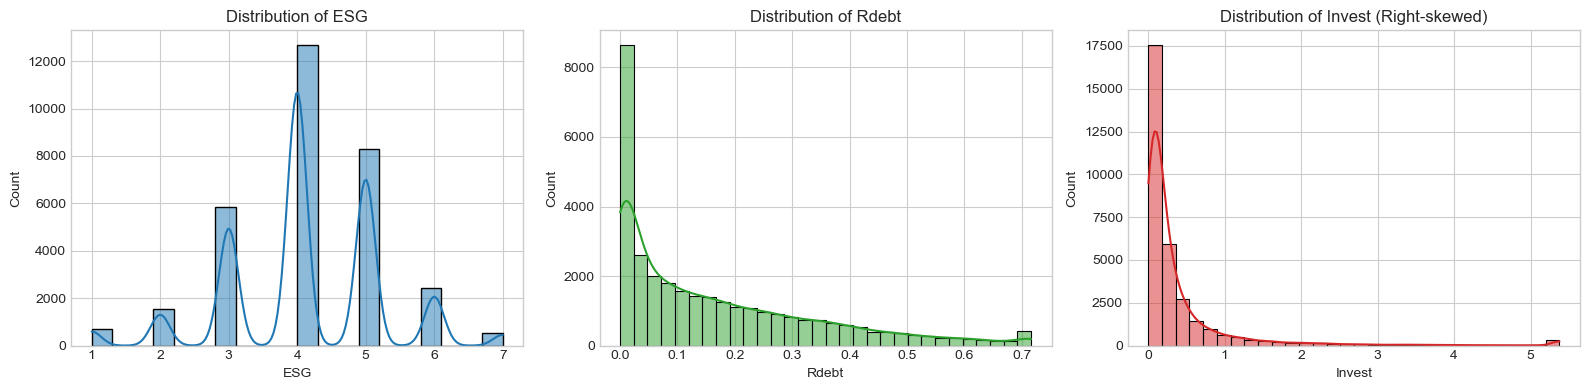

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['ESG'], bins=20, kde=True, ax=axes[0], color='#1f77b4')
axes[0].set_title('Distribution of ESG')

sns.histplot(df['Rdebt'], bins=30, kde=True, ax=axes[1], color='#2ca02c')
axes[1].set_title('Distribution of Rdebt')

sns.histplot(df['Invest'], bins=30, kde=True, ax=axes[2], color='#d62728')
axes[2].set_title('Distribution of Invest (Right-skewed)')

plt.tight_layout()
plt.show()

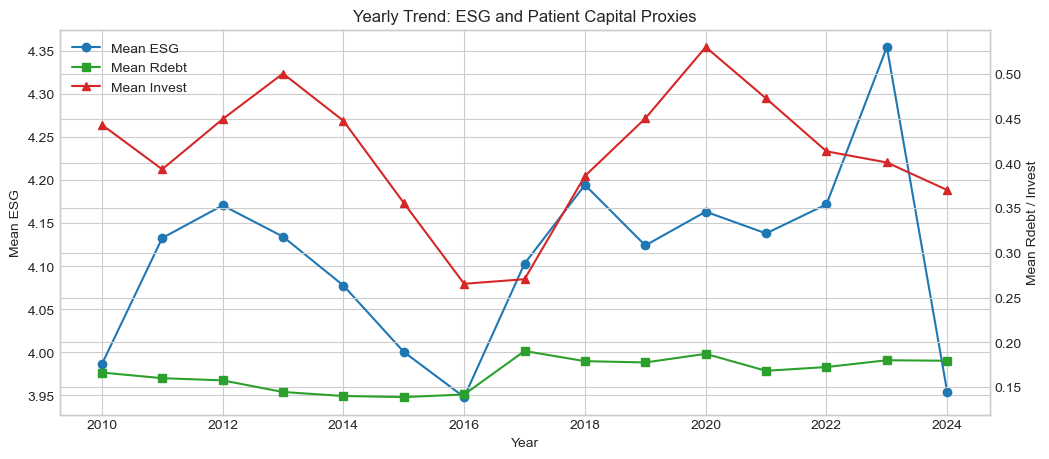

In [8]:
yearly = df.groupby('Year')[['ESG', 'Rdebt', 'Invest']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(yearly['Year'], yearly['ESG'], marker='o', label='Mean ESG', color='#1f77b4')
ax1.set_ylabel('Mean ESG')
ax1.set_xlabel('Year')
ax1.set_title('Yearly Trend: ESG and Patient Capital Proxies')

ax2 = ax1.twinx()
ax2.plot(yearly['Year'], yearly['Rdebt'], marker='s', label='Mean Rdebt', color='#2ca02c')
ax2.plot(yearly['Year'], yearly['Invest'], marker='^', label='Mean Invest', color='#d62728')
ax2.set_ylabel('Mean Rdebt / Invest')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.show()

## 6) Correlation Structure

This helps beginners see raw associations before regression controls.

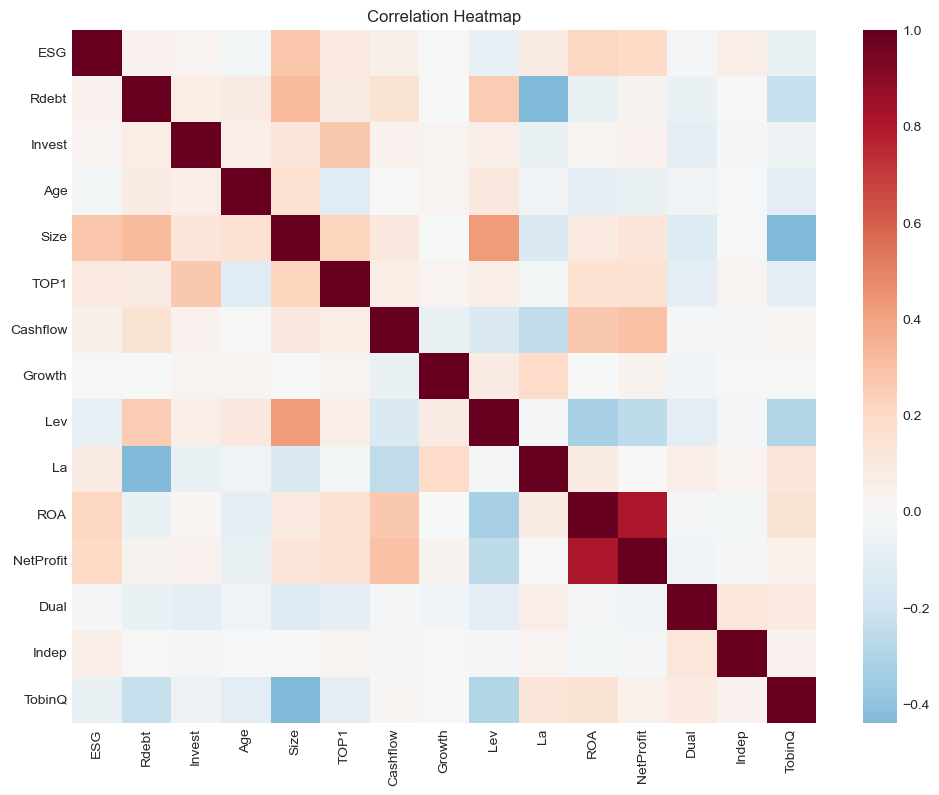

,ESG
ESG,1.000
Size,0.276
ROA,0.218
NetProfit,0.198
TOP1,0.097
La,0.079
Indep,0.070
Cashflow,0.060
Rdebt,0.042
Invest,0.031


In [9]:
corr_vars = ['ESG','Rdebt','Invest','Age','Size','TOP1','Cashflow','Growth','Lev','La','ROA','NetProfit','Dual','Indep','TobinQ']
corr = df[corr_vars].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.show()

corr[['ESG']].sort_values('ESG', ascending=False).round(3)

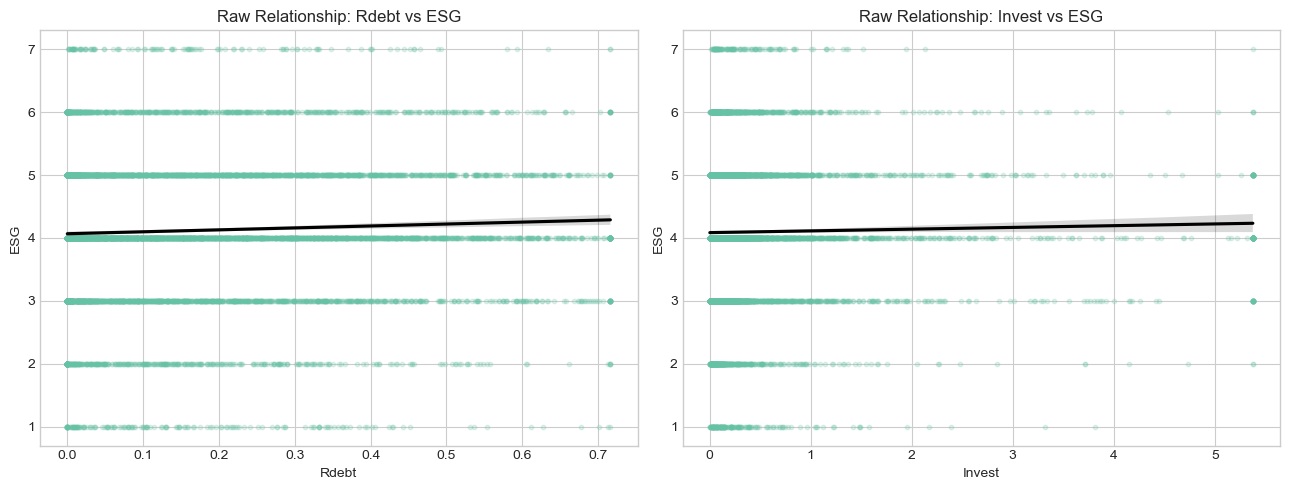

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.regplot(data=df.sample(min(len(df), 8000), random_state=42), x='Rdebt', y='ESG', scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'black'}, ax=axes[0])
axes[0].set_title('Raw Relationship: Rdebt vs ESG')

sns.regplot(data=df.sample(min(len(df), 8000), random_state=43), x='Invest', y='ESG', scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'black'}, ax=axes[1])
axes[1].set_title('Raw Relationship: Invest vs ESG')

plt.tight_layout()
plt.show()

## 7) Baseline Empirical Model

We replicate the core idea using OLS with industry and year fixed effects:

`ESG = a0 + a1*PC + Controls + Industry FE + Year FE + error`

Controls:
`Age Size TOP1 Cashflow Growth Lev La ROA NetProfit Dual Indep TobinQ`

In [11]:
controls = ['Age','Size','TOP1','Cashflow','Growth','Lev','La','ROA','NetProfit','Dual','Indep','TobinQ']
ctrl = ' + '.join(controls)

formula_rdebt_noctrl = 'ESG ~ Rdebt + C(Year) + C(IndustryCode)'
formula_rdebt_ctrl = f'ESG ~ Rdebt + {ctrl} + C(Year) + C(IndustryCode)'
formula_invest_noctrl = 'ESG ~ Invest + C(Year) + C(IndustryCode)'
formula_invest_ctrl = f'ESG ~ Invest + {ctrl} + C(Year) + C(IndustryCode)'

model_r1 = smf.ols(formula_rdebt_noctrl, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['Scode']})
model_r2 = smf.ols(formula_rdebt_ctrl, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['Scode']})
model_i1 = smf.ols(formula_invest_noctrl, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['Scode']})
model_i2 = smf.ols(formula_invest_ctrl, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['Scode']})

res = pd.DataFrame([
    ('Rdebt', 'No controls + FE', model_r1.params['Rdebt'], model_r1.tvalues['Rdebt'], model_r1.pvalues['Rdebt'], int(model_r1.nobs), model_r1.rsquared_adj),
    ('Rdebt', 'With controls + FE', model_r2.params['Rdebt'], model_r2.tvalues['Rdebt'], model_r2.pvalues['Rdebt'], int(model_r2.nobs), model_r2.rsquared_adj),
    ('Invest', 'No controls + FE', model_i1.params['Invest'], model_i1.tvalues['Invest'], model_i1.pvalues['Invest'], int(model_i1.nobs), model_i1.rsquared_adj),
    ('Invest', 'With controls + FE', model_i2.params['Invest'], model_i2.tvalues['Invest'], model_i2.pvalues['Invest'], int(model_i2.nobs), model_i2.rsquared_adj),
], columns=['PC','Model','Coef','t','p','N','Adj_R2'])

res.round(4)

,PC,Model,Coef,t,p,N,Adj_R2
0,Rdebt,No controls + FE,0.3844,5.6971,0.0000,32023,0.0579
1,Rdebt,With controls + FE,0.3048,5.1945,0.0000,32023,0.2123
2,Invest,No controls + FE,0.0537,5.0563,0.0000,32023,0.0565
3,Invest,With controls + FE,0.0161,1.8018,0.0716,32023,0.2110


### Compare with Existing Replication Output (from project CSV tables)

In [12]:
compare = pd.concat([
    baseline_rdebt[['Column','Model','PC_coef','PC_tstat','PC_pval','N','Adj_R2']].assign(PC='Rdebt'),
    baseline_invest[['Column','Model','PC_coef','PC_tstat','PC_pval','N','Adj_R2']].assign(PC='Invest')
], ignore_index=True)

compare[['PC','Column','Model','PC_coef','PC_tstat','PC_pval','N','Adj_R2']].round(4)

,PC,Column,Model,PC_coef,PC_tstat,PC_pval,N,Adj_R2
0,Rdebt,(1),"Pooled OLS, PC only + Ind/Year FE",0.3844,5.6983,0.0000,32010,0.0575
1,Rdebt,(2),"Pooled OLS, PC + Controls + Ind/Year FE",0.3048,5.1955,0.0000,32010,0.2119
2,Rdebt,(3),Firm FE + Year FE + Controls,0.2118,3.3250,0.0009,31534,0.4233
3,Rdebt,(4),Random Effects,0.2942,5.5263,0.0000,32023,NaN
4,Invest,(1),"Pooled OLS, PC only + Ind/Year FE",0.0537,5.0574,0.0000,32010,0.0561
5,Invest,(2),"Pooled OLS, PC + Controls + Ind/Year FE",0.0161,1.8022,0.0716,32010,0.2106
6,Invest,(3),Firm FE + Year FE + Controls,0.0196,2.3610,0.0183,31534,0.4231
7,Invest,(4),Random Effects,0.0219,2.8177,0.0048,32023,NaN


## 8) Simple Robustness Example

We run a lagged-PC check (a beginner-friendly way to reduce reverse-causality concerns).

In [13]:
df_lag = df.sort_values(['Scode','Year']).copy()
df_lag['Rdebt_lag1'] = df_lag.groupby('Scode')['Rdebt'].shift(1)
df_lag['Invest_lag1'] = df_lag.groupby('Scode')['Invest'].shift(1)

lag_data = df_lag.dropna(subset=['Rdebt_lag1','Invest_lag1'])

formula_r_lag = f'ESG ~ Rdebt_lag1 + {ctrl} + C(Year) + C(IndustryCode)'
formula_i_lag = f'ESG ~ Invest_lag1 + {ctrl} + C(Year) + C(IndustryCode)'

m_r_lag = smf.ols(formula_r_lag, data=lag_data).fit(cov_type='cluster', cov_kwds={'groups': lag_data['Scode']})
m_i_lag = smf.ols(formula_i_lag, data=lag_data).fit(cov_type='cluster', cov_kwds={'groups': lag_data['Scode']})

pd.DataFrame([
    ('Rdebt_lag1', m_r_lag.params['Rdebt_lag1'], m_r_lag.tvalues['Rdebt_lag1'], m_r_lag.pvalues['Rdebt_lag1'], int(m_r_lag.nobs)),
    ('Invest_lag1', m_i_lag.params['Invest_lag1'], m_i_lag.tvalues['Invest_lag1'], m_i_lag.pvalues['Invest_lag1'], int(m_i_lag.nobs)),
], columns=['Variable','Coef','t','p','N']).round(4)

,Variable,Coef,t,p,N
0,Rdebt_lag1,0.1728,2.7925,0.0052,27707
1,Invest_lag1,-0.0050,-0.5442,0.5863,27707


## 9) ESG Sub-Dimensions (E, S, G)

This shows where the effect mainly comes from.

In [14]:
sub_results = []
for y in ['E_Score', 'S_Score', 'G_Score']:
    f_r = f'{y} ~ Rdebt + {ctrl} + C(Year) + C(IndustryCode)'
    f_i = f'{y} ~ Invest + {ctrl} + C(Year) + C(IndustryCode)'
    mr = smf.ols(f_r, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['Scode']})
    mi = smf.ols(f_i, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['Scode']})
    sub_results.append((y, 'Rdebt', mr.params['Rdebt'], mr.tvalues['Rdebt'], mr.pvalues['Rdebt']))
    sub_results.append((y, 'Invest', mi.params['Invest'], mi.tvalues['Invest'], mi.pvalues['Invest']))

sub_df = pd.DataFrame(sub_results, columns=['DV','PC','Coef','t','p'])
sub_df.round(4)

,DV,PC,Coef,t,p
0,E_Score,Rdebt,-0.4959,-1.2674,0.2050
1,E_Score,Invest,0.0952,1.4370,0.1507
2,S_Score,Rdebt,0.7666,1.4531,0.1462
3,S_Score,Invest,-0.3316,-4.0728,0.0000
4,G_Score,Rdebt,3.2248,9.5330,0.0000
5,G_Score,Invest,0.2486,4.9617,0.0000


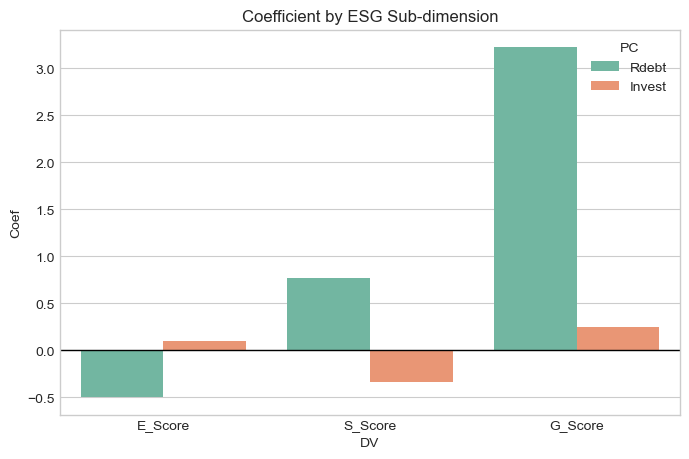

In [15]:
plt.figure(figsize=(8,5))
plot_df = sub_df.copy()
plot_df['label'] = plot_df['DV'] + ' | ' + plot_df['PC']

sns.barplot(data=plot_df, x='DV', y='Coef', hue='PC')
plt.axhline(0, color='black', linewidth=1)
plt.title('Coefficient by ESG Sub-dimension')
plt.show()

## 10) Beginner Interpretation Guide

How to read a coefficient in this project:
- If `Rdebt` coefficient is positive and significant, higher long-term patient debt orientation is associated with higher ESG.
- If `Invest` coefficient is small/unstable, the effect exists but depends more on controls and sample specification.

Why fixed effects matter:
- `Year FE` controls for macro shocks by year.
- `Industry FE` controls for stable sector differences.
- Clustered standard errors at firm level account for within-firm dependence over time.

Core empirical conclusion from this project:
- `Rdebt` effect is robust and consistently positive.
- `Invest` effect is weaker and less stable, often sensitive to controls like `Size` and `TOP1`.


## 11) What to Explore Next

1. Re-run models with firm fixed effects (`C(Scode)`) on a smaller sample (computationally heavy in plain OLS).
2. Reproduce mechanism tests (SA, AgencyCost, IneffInvest, innovation).
3. Build heterogeneity subsamples (SOE vs non-SOE, heavy-pollution vs others).
4. Extend to NGAP (`ESG gap`) as in the project report.

This notebook is designed as a learning bridge: concept -> data -> model -> interpretation.


## 12) Questions and Answers Archive (All Project Q&A Files)

This section demonstrates all identified Q&A files in the project and renders their text content inside the notebook.

In [16]:
from pathlib import Path
import zipfile
import re

qa_files = [
    Path(r'论文数据0208/论文数据0208/实证分析疑问.docx'),
    Path(r'论文数据0208/论文数据0208/D1/回复.docx'),
    Path(r'论文数据0208/论文数据0208/D1/问题回复_QA.md'),
    Path(r'论文数据0208/论文数据0208/22FEB/其q3.md'),
    Path(r'论文数据0208/论文数据0208/22FEB/detailed_response.md'),
    Path(r'论文数据0208/论文数据0208/22FEB/questions_summary.md'),
]

qa_index = []
for p in qa_files:
    qa_index.append({
        'file': str(p),
        'exists': p.exists(),
        'size_bytes': p.stat().st_size if p.exists() else None,
        'ext': p.suffix.lower()
    })

pd.DataFrame(qa_index)

,file,exists,size_bytes,ext
0,论文数据0208\论文数据0208\实证分析疑问.docx,True,187648,.docx
1,论文数据0208\论文数据0208\D1\回复.docx,True,21556,.docx
2,论文数据0208\论文数据0208\D1\问题回复_QA.md,True,13000,.md
3,论文数据0208\论文数据0208\22FEB\其q3.md,True,245,.md
4,论文数据0208\论文数据0208\22FEB\detailed_response.md,True,3895,.md
5,论文数据0208\论文数据0208\22FEB\questions_summary.md,True,3911,.md


In [17]:
def read_docx_text(path: Path) -> str:
    with zipfile.ZipFile(path, 'r') as zf:
        xml = zf.read('word/document.xml').decode('utf-8', errors='ignore')
    text = re.sub(r'</w:p>', '\n', xml)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

def read_text_file(path: Path) -> str:
    for enc in ['utf-8', 'utf-8-sig', 'gb18030', 'gbk', 'latin-1']:
        try:
            return path.read_text(encoding=enc)
        except Exception:
            pass
    return '[Unable to decode text file]'

def read_any(path: Path) -> str:
    ext = path.suffix.lower()
    if not path.exists():
        return '[File not found]'
    if ext == '.docx':
        return read_docx_text(path)
    if ext in ['.md', '.txt', '.rtf', '.doc']:
        return read_text_file(path)
    return f'[Unsupported extension: {ext}]'

In [18]:
# Set True if you want full text for every file in one run
SHOW_FULL_TEXT = True
PREVIEW_CHARS = 6000

for i, p in enumerate(qa_files, 1):
    print('='*100)
    print(f'[{i}] {p}')
    print('='*100)
    txt = read_any(p)
    if SHOW_FULL_TEXT:
        print(txt)
    else:
        print(txt[:PREVIEW_CHARS])
        if len(txt) > PREVIEW_CHARS:
            print(f'\n... [truncated: total {len(txt)} chars]')
    print('\n')

[1] 论文数据0208\论文数据0208\实证分析疑问.docx
实证分析的一些疑问——
我跑数据，导入dta文件的观测值是31834
-215901077595关于相关性系数
相关性系数表格输出，需要截断，因为15*15放在文档里太挤，这个我在修改输出格式时一直报错，所以希望老师帮我修改一下这一块（表格格式如下）

二、关于中介机制
因为机制检验还要对应前面的假设以及模型，回归数据中把所有现有的中介变量都跑了，是否需要进行取舍，老师有什么建议吗
86360331470一般论文中的中介机制输出格式如下

三、关于异质性分析
21590230505在实际输出过程中也是系数上标星，系数下面（t值），具体格式如下

因为老师输出表格的格式与硕士论文要求不一样，所以想改一下代码。
但是我在重新跑数据的时候，基准回归观测数31834，麻烦老师帮我看一下，我是不是不小心把老师的正确代码改错了


[2] 论文数据0208\论文数据0208\D1\回复.docx
论文问题回复
Q1：09年的数据有什么问题？为什么数据区间从09-24变成了10-24？答辩老师会质疑吗？

Invest变量构造需要滞后数据： Invest = INVH / SD(INVH_{t-1}, INVH_{t-2}, INVH_{t-3})，计算2009年的Invest需要2006-2008年的机构持股数据。虽然原始数据中保留了这些，但滞后3年的标准差计算会导致早期年份缺失较多。
2009年ESG覆盖面窄： 华证ESG评级虽然从2009年开始，但当年覆盖的上市公司数量极少（样本量约1,148家在2010年，2009年更少），数据代表性和质量不如后续年份。
“本文ESG数据来源于华证指数ESG评级（2009-2024）。由于2009年ESG评级覆盖企业数量较少、评级体系尚处于初始阶段，且核心解释变量（稳定型股权Invest）的构造需要前3年机构持股数据的滞后项，为保证数据质量和样本完整性，最终有效样本期间为2010-2024年，共32,023个公司-年度观测值。”
这是非常常见的做法，答辩老师一般不会在这个点上深究。如果追问，可以补充说做了2009年包含在内的稳健性检验，结果一致。

Q2：稳定型股权（Invest）的衡量方式？加入控制变量后从两颗星变成一颗星？
衡量方式
Invest的构造如下：
Inve

### Notes
- This archive section is dynamic: it reads the original files from folders each time you run it.
- If any Q&A file gets updated, re-run this section to show the latest version in the notebook.